# Lec3 — Gaussian Mixture Models
### From One Gaussian to Many: Learning Structure in Data

This notebook builds the Gaussian Mixture Model (GMM) from the ground up.
We start by asking why a single Gaussian is not enough, then define the mixture model mathematically,
draw samples from it, and formalize its likelihood.
The core of the notebook is a from-scratch implementation of the **Expectation-Maximization (EM)**
algorithm — the classic iterative method for fitting GMMs.
We watch EM converge step by step, then compare our result to `sklearn`.
By the end you will understand both *what* a GMM is and *how* it is fitted.

## Part 1 — Why One Gaussian Is Not Enough

In Lec2 we fitted a single Gaussian to data. That works beautifully when the data comes from one cluster.
But real data rarely cooperates:

- Heights of people: one cluster
- Heights of people **split by biological sex**: two overlapping clusters
- Customer spending patterns: high-spenders, casual shoppers, bargain hunters — multiple clusters

When you force a single Gaussian onto multi-modal data, the fit is poor:
the single Gaussian smears across all clusters and captures none of them well.

The fix is simple in concept: **use several Gaussians, one per cluster, and blend them**.
That blend is the Gaussian Mixture Model.

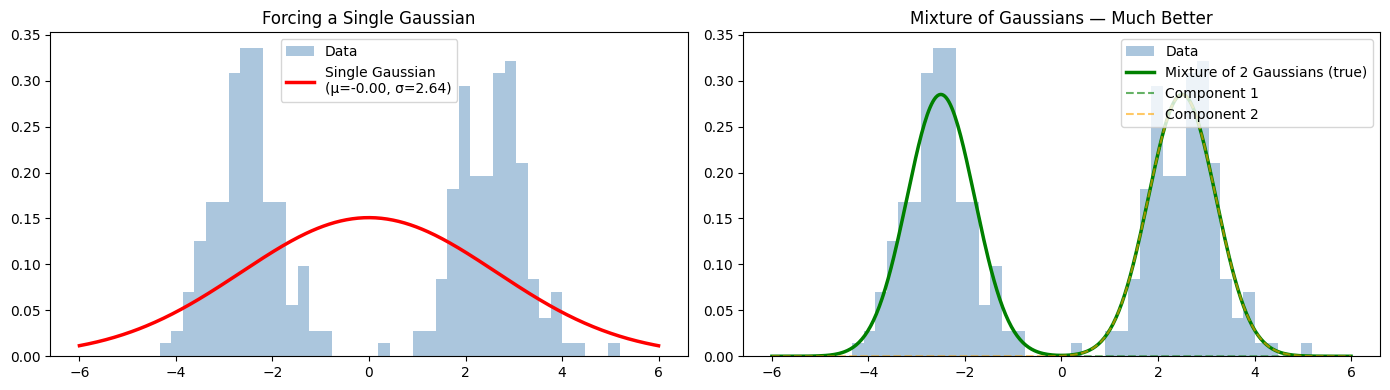

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# Two-cluster data that a single Gaussian cannot describe well
cluster1 = np.random.normal(-2.5, 0.7, 150)
cluster2 = np.random.normal( 2.5, 0.7, 150)
data = np.concatenate([cluster1, cluster2])

x_plot = np.linspace(-6, 6, 400)

# Best single Gaussian (MLE): mean and std of combined data
mu_single    = data.mean()
sigma_single = data.std()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left — histogram + bad single Gaussian
axes[0].hist(data, bins=40, density=True, alpha=0.45, color='steelblue', label='Data')
axes[0].plot(x_plot, norm.pdf(x_plot, mu_single, sigma_single),
             'r-', lw=2.5, label=f'Single Gaussian\n(μ={mu_single:.2f}, σ={sigma_single:.2f})')
axes[0].set_title('Forcing a Single Gaussian')
axes[0].legend()

# Right — histogram + two-component mixture (true)
axes[1].hist(data, bins=40, density=True, alpha=0.45, color='steelblue', label='Data')
axes[1].plot(x_plot, 0.5 * norm.pdf(x_plot, -2.5, 0.7) +
                      0.5 * norm.pdf(x_plot,  2.5, 0.7),
             'g-', lw=2.5, label='Mixture of 2 Gaussians (true)')
axes[1].plot(x_plot, 0.5 * norm.pdf(x_plot, -2.5, 0.7), 'g--', lw=1.5, alpha=0.6, label='Component 1')
axes[1].plot(x_plot, 0.5 * norm.pdf(x_plot,  2.5, 0.7), 'orange', lw=1.5, ls='--', alpha=0.6, label='Component 2')
axes[1].set_title('Mixture of Gaussians — Much Better')
axes[1].legend()

plt.tight_layout()
plt.show()

## Part 2 — The GMM Model: Parameters and Formula

A **Gaussian Mixture Model** with $K$ components defines the probability of a data point $x$ as:

$$p(x) = \sum_{k=1}^{K} \pi_k \; \mathcal{N}(x \mid \mu_k, \sigma_k)$$

There are **three sets of parameters** — one set per component:

| Symbol | Name | Meaning |
|--------|------|---------|
| $\pi_k$ | **mixing weight** | How often this component is chosen. Must satisfy $\pi_k \ge 0$ and $\sum_k \pi_k = 1$. |
| $\mu_k$ | **mean** | Where the $k$-th Gaussian is centered. |
| $\sigma_k$ | **standard deviation** | How wide the $k$-th Gaussian is. |

Think of it as a **two-step generative story**:
1. Flip a (weighted) $K$-sided coin → pick component $k$ with probability $\pi_k$.
2. Draw a sample from $\mathcal{N}(\mu_k, \sigma_k)$.

We observe only the final sample — **we never see which component generated it**.
That hidden assignment is what makes fitting a GMM tricky.

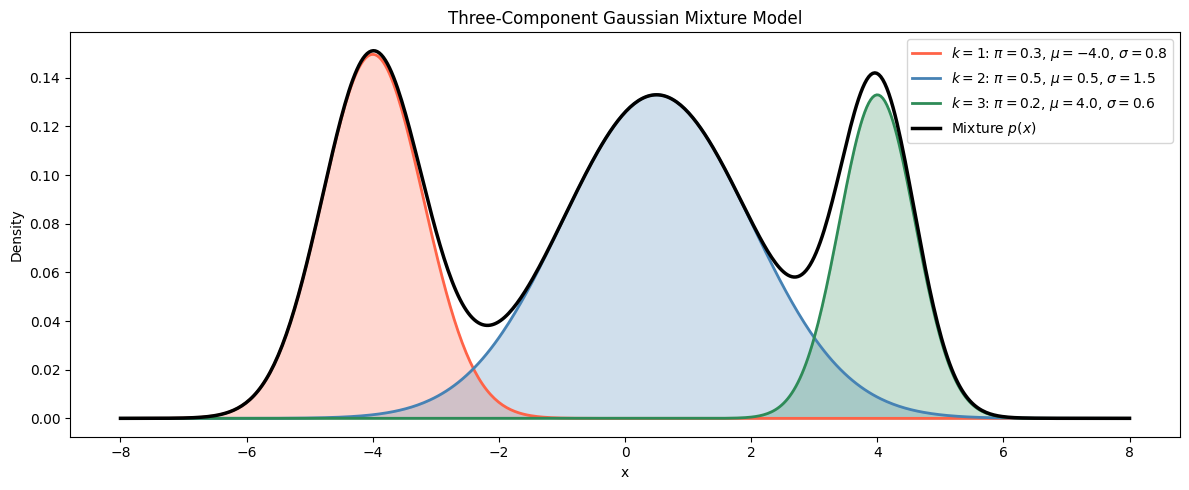

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Visualise the GMM formula: components + mixture ---
x_plot = np.linspace(-8, 8, 500)

# Three-component GMM
pis    = [0.3,  0.5,  0.2]
mus    = [-4.0,  0.5,  4.0]
sigmas = [ 0.8,  1.5,  0.6]
colors = ['tomato', 'steelblue', 'seagreen']

mixture = np.zeros_like(x_plot)
fig, ax = plt.subplots(figsize=(12, 5))

for k, (pi, mu, sigma, color) in enumerate(zip(pis, mus, sigmas, colors)):
    component = pi * norm.pdf(x_plot, mu, sigma)
    mixture  += component
    ax.fill_between(x_plot, component, alpha=0.25, color=color)
    ax.plot(x_plot, component, color=color, lw=2,
            label=fr'$k={k+1}$: $\pi={pi}$, $\mu={mu}$, $\sigma={sigma}$')

ax.plot(x_plot, mixture, 'k-', lw=2.5, label='Mixture $p(x)$')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('Three-Component Gaussian Mixture Model')
ax.legend()
plt.tight_layout()
plt.show()

## Part 3 — Sampling From a GMM

Because the GMM has a clean generative story, sampling is easy:

1. Draw a component index $z \in \{1, \ldots, K\}$ with probabilities $[\pi_1, \ldots, \pi_K]$.
2. Draw $x \sim \mathcal{N}(\mu_z, \sigma_z)$.

The color in the plot below shows the **true (hidden) component label** — in practice,
this is **unobserved**. Our fitting algorithm must infer it.

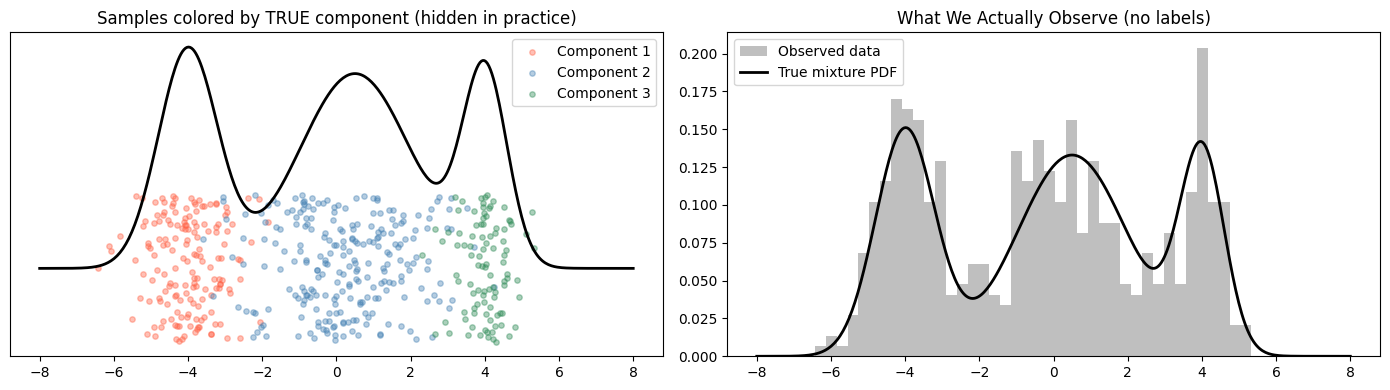

Samples per component (true): [np.int64(162), np.int64(240), np.int64(98)]


In [3]:
np.random.seed(0)

# True GMM parameters
pis_true    = np.array([0.3, 0.5, 0.2])
mus_true    = np.array([-4.0, 0.5, 4.0])
sigmas_true = np.array([0.8, 1.5, 0.6])
K = len(pis_true)
N = 500

# Step 1: draw component labels
z = np.random.choice(K, size=N, p=pis_true)      # shape (N,)

# Step 2: draw samples from assigned components
x_samples = np.array([np.random.normal(mus_true[zi], sigmas_true[zi]) for zi in z])

x_plot = np.linspace(-8, 8, 400)
mixture_pdf = sum(pi * norm.pdf(x_plot, mu, sigma)
                  for pi, mu, sigma in zip(pis_true, mus_true, sigmas_true))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: colored by true component (normally hidden!)
for k in range(K):
    axes[0].scatter(x_samples[z == k], np.zeros(np.sum(z == k)) + np.random.uniform(-0.05, 0.05, np.sum(z == k)),
                    alpha=0.4, s=15, color=colors[k], label=f'Component {k+1}')
axes[0].plot(x_plot, mixture_pdf, 'k-', lw=2)
axes[0].set_yticks([])
axes[0].set_title('Samples colored by TRUE component (hidden in practice)')
axes[0].legend()

# Right: what we actually observe — unlabeled
axes[1].hist(x_samples, bins=40, density=True, alpha=0.5, color='gray', label='Observed data')
axes[1].plot(x_plot, mixture_pdf, 'k-', lw=2, label='True mixture PDF')
axes[1].set_title('What We Actually Observe (no labels)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Samples per component (true): {[(z==k).sum() for k in range(K)]}')

## Part 4 — The Log-Likelihood of a GMM

To fit a GMM we want to maximize the probability of the observed data.
For $N$ i.i.d. observations $\{x_1, \ldots, x_N\}$, the **log-likelihood** is:

$$\log \mathcal{L}(\boldsymbol{\pi}, \boldsymbol{\mu}, \boldsymbol{\sigma}) =
\sum_{i=1}^{N} \log \left( \sum_{k=1}^{K} \pi_k \; \mathcal{N}(x_i \mid \mu_k, \sigma_k) \right)$$

**Why can't we just use gradient descent like in Lec2?**

The $\log$ of a *sum* is painful:
- No closed-form solution.
- Gradient descent works, but naive implementation is slow and ignores the constraints $\sum_k \pi_k = 1$.
- There's a smarter algorithm purpose-built for this: **Expectation-Maximization (EM)**.

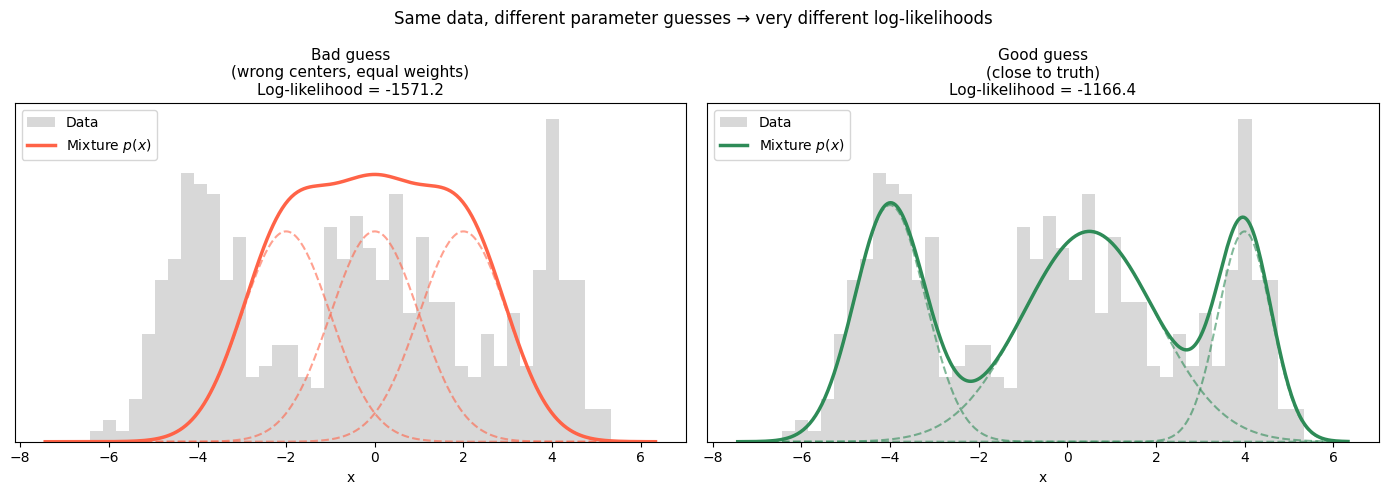

Bad guess  LL: -1571.23
Good guess LL: -1166.43
Higher log-likelihood = better fit.


In [4]:
from scipy.special import logsumexp

def gmm_log_likelihood(x, pis, mus, sigmas):
    """Log-likelihood of data x under a GMM with given parameters."""
    log_resp = np.array([
        np.log(pi) + norm.logpdf(x, mu, sigma)
        for pi, mu, sigma in zip(pis, mus, sigmas)
    ]).T  # (N, K)
    return logsumexp(log_resp, axis=1).sum()

# ── Define a bad and a good guess ────────────────────────────────────────────
guesses = {
    'Bad guess\n(wrong centers, equal weights)': {
        'pis':    [1/3, 1/3, 1/3],
        'mus':    [-2.0, 0.0, 2.0],
        'sigmas': [1.0,  1.0, 1.0],
        'color':  'tomato',
    },
    'Good guess\n(close to truth)': {
        'pis':    pis_true,
        'mus':    mus_true,
        'sigmas': sigmas_true,
        'color':  'seagreen',
    },
}

x_plot = np.linspace(x_samples.min() - 1, x_samples.max() + 1, 400)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, g) in zip(axes, guesses.items()):
    ll = gmm_log_likelihood(x_samples, g['pis'], g['mus'], g['sigmas'])
    mixture = sum(pi * norm.pdf(x_plot, mu, sigma)
                  for pi, mu, sigma in zip(g['pis'], g['mus'], g['sigmas']))

    ax.hist(x_samples, bins=40, density=True, alpha=0.3, color='gray', label='Data')
    ax.plot(x_plot, mixture, color=g['color'], lw=2.5, label='Mixture $p(x)$')
    for k in range(len(g['pis'])):
        ax.plot(x_plot, g['pis'][k] * norm.pdf(x_plot, g['mus'][k], g['sigmas'][k]),
                ls='--', lw=1.5, color=g['color'], alpha=0.6)

    ax.set_title(f'{title}\nLog-likelihood = {ll:.1f}', fontsize=11)
    ax.set_xlabel('x')
    ax.set_yticks([])
    ax.legend()

plt.suptitle('Same data, different parameter guesses → very different log-likelihoods', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Bad guess  LL: {gmm_log_likelihood(x_samples, [1/3,1/3,1/3], [-2.,0.,2.], [1.,1.,1.]):.2f}')
print(f'Good guess LL: {gmm_log_likelihood(x_samples, pis_true, mus_true, sigmas_true):.2f}')
print('Higher log-likelihood = better fit.')

## Part 4.5 — Can't We Just Use Gradient Descent? (PyTorch Attempt)

In Lec2 we fit a single Gaussian with PyTorch + Adam and it worked beautifully.
Let's try the same trick here: treat $(\boldsymbol{\pi}, \boldsymbol{\mu}, \boldsymbol{\sigma})$ as learnable parameters
and minimise the **negative log-likelihood** with gradient descent.

### The objective

$$\mathcal{L}(\boldsymbol{\pi}, \boldsymbol{\mu}, \boldsymbol{\sigma}) =
-\sum_{i=1}^{N} \log \underbrace{\left( \sum_{k=1}^{K} \pi_k \; \mathcal{N}(x_i \mid \mu_k, \sigma_k) \right)}_{p(x_i)}$$

We want to **minimise** this (equivalently, maximise the log-likelihood).

### Constraints we must enforce
Because $\pi_k$ are probabilities they must satisfy $\pi_k \ge 0$ and $\sum_k \pi_k = 1$.
Raw gradient steps ignore these, so we reparametrise:

$$\pi_k = \frac{e^{\alpha_k}}{\sum_j e^{\alpha_j}} \quad \text{(softmax of free logits } \boldsymbol{\alpha}\text{)}, \qquad \sigma_k = e^{\ell_k} \quad \text{(exp of free log-std } \ell_k\text{)}$$

**Spoiler: it mostly works… but there are real problems:**

1. **Local minima.** With $K$ components, any permutation of labels is equally valid.
   Adam can converge to very different solutions depending on initialisation.

2. **Component merging.** Two components may collapse onto the same cluster,
   leaving one cluster entirely uncovered — and Adam never "knows" this is wrong.

3. **No monotone guarantee.** Unlike EM, gradient descent can overshoot and the loss
   can oscillate rather than decrease smoothly.

Let's see this empirically.

NLL across 20 random seeds:  min=1161.4  max=1218.5  spread=57.2
Best  seed=13   NLL=1161.4
Worst seed=9  NLL=1218.5


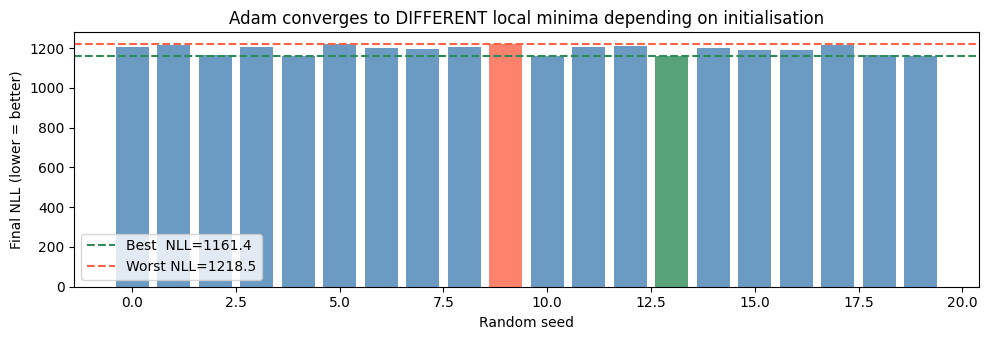

In [5]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x_torch = torch.tensor(x_samples, dtype=torch.float32)
K = 3

def gmm_nll_torch(x, pi_logits, mus, log_sigmas):
    """Negative log-likelihood of a GMM (PyTorch, differentiable)."""
    pis    = F.softmax(pi_logits, dim=0)
    sigmas = torch.exp(log_sigmas)
    log_components = (
        torch.log(pis)[None, :]
        - log_sigmas[None, :]
        - 0.5 * np.log(2 * np.pi)
        - 0.5 * ((x[:, None] - mus[None, :]) / sigmas[None, :]) ** 2
    )
    return -torch.logsumexp(log_components, dim=1).sum()

def run_adam(seed, n_iters=500, lr=0.05):
    torch.manual_seed(seed)
    pi_logits  = torch.randn(K, requires_grad=True)
    mus_t      = torch.randn(K, requires_grad=True)
    log_sigmas = torch.zeros(K, requires_grad=True)
    opt = torch.optim.Adam([pi_logits, mus_t, log_sigmas], lr=lr)
    for _ in range(n_iters):
        opt.zero_grad()
        gmm_nll_torch(x_torch, pi_logits, mus_t, log_sigmas).backward()
        opt.step()
    with torch.no_grad():
        return (F.softmax(pi_logits, dim=0).numpy().copy(),
                mus_t.numpy().copy(),
                torch.exp(log_sigmas).numpy().copy(),
                gmm_nll_torch(x_torch, pi_logits, mus_t, log_sigmas).item())

# ── Run 20 random seeds ───────────────────────────────────────────────────────
seeds   = list(range(20))
results = [run_adam(s) for s in seeds]
nlls    = [r[3] for r in results]

best_idx  = int(np.argmin(nlls))
worst_idx = int(np.argmax(nlls))

print(f'NLL across 20 random seeds:  min={min(nlls):.1f}  max={max(nlls):.1f}  spread={max(nlls)-min(nlls):.1f}')
print(f'Best  seed={seeds[best_idx]}   NLL={nlls[best_idx]:.1f}')
print(f'Worst seed={seeds[worst_idx]}  NLL={nlls[worst_idx]:.1f}')

# ── Plot 1: NLL scatter across seeds ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(seeds, nlls, color=['seagreen' if i == best_idx else
                            'tomato'  if i == worst_idx else
                            'steelblue' for i in range(len(seeds))], alpha=0.8)
ax.axhline(nlls[best_idx],  color='seagreen', ls='--', lw=1.5, label=f'Best  NLL={nlls[best_idx]:.1f}')
ax.axhline(nlls[worst_idx], color='tomato',   ls='--', lw=1.5, label=f'Worst NLL={nlls[worst_idx]:.1f}')
ax.set_xlabel('Random seed')
ax.set_ylabel('Final NLL (lower = better)')
ax.set_title('Adam converges to DIFFERENT local minima depending on initialisation')
ax.legend()
plt.tight_layout()
plt.show()

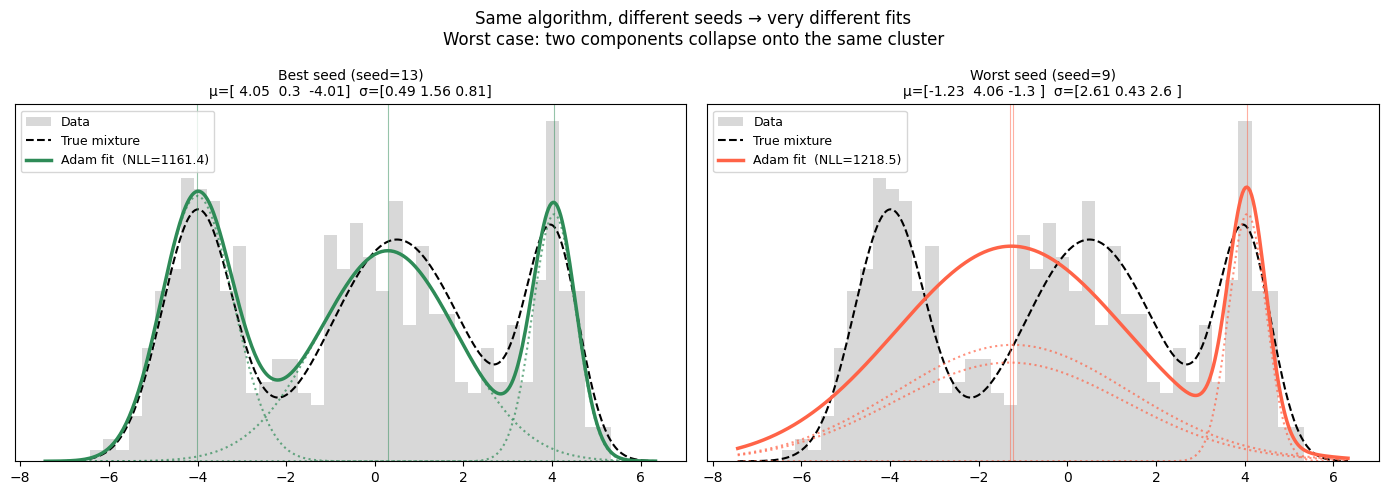

Worst-case parameters (sorted by μ):
  k=3: π=0.385  μ=-1.301  σ=2.595
  k=1: π=0.456  μ=-1.227  σ=2.608
  k=2: π=0.158  μ=4.065  σ=0.426

True parameters (sorted by μ):
  k=1: π=0.300  μ=-4.000  σ=0.800
  k=2: π=0.500  μ=0.500  σ=1.500
  k=3: π=0.200  μ=4.000  σ=0.600

Notice: in the worst case, two components share a region with a bloated σ,
while the third cluster is underfitted. Adam has no way to "know" this is wrong.


In [6]:
# ── Plot 2: Best vs Worst fit side by side ───────────────────────────────────
x_plot = np.linspace(x_samples.min() - 1, x_samples.max() + 1, 400)
mixture_true = sum(pi * norm.pdf(x_plot, mu, sigma)
                   for pi, mu, sigma in zip(pis_true, mus_true, sigmas_true))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, idx, label, color in [
    (axes[0], best_idx,  'Best seed',  'seagreen'),
    (axes[1], worst_idx, 'Worst seed', 'tomato'),
]:
    pis_r, mus_r, sigmas_r, nll_r = results[idx]
    mixture_r = sum(pi * norm.pdf(x_plot, mu, sigma)
                    for pi, mu, sigma in zip(pis_r, mus_r, sigmas_r))

    ax.hist(x_samples, bins=40, density=True, alpha=0.3, color='gray', label='Data')
    ax.plot(x_plot, mixture_true, 'k--', lw=1.5, label='True mixture')
    ax.plot(x_plot, mixture_r,    color=color, lw=2.5, label=f'Adam fit  (NLL={nll_r:.1f})')
    for k in range(K):
        ax.plot(x_plot, pis_r[k] * norm.pdf(x_plot, mus_r[k], sigmas_r[k]),
                ls=':', lw=1.5, color=color, alpha=0.7)

    # Annotate estimated means
    order = np.argsort(mus_r)
    for k in order:
        ax.axvline(mus_r[k], color=color, lw=0.8, alpha=0.5)

    ax.set_title(f'{label} (seed={seeds[idx]})\n'
                 f'μ={mus_r.round(2)}  σ={sigmas_r.round(2)}', fontsize=10)
    ax.set_yticks([])
    ax.legend(fontsize=9)

plt.suptitle('Same algorithm, different seeds → very different fits\n'
             'Worst case: two components collapse onto the same cluster', fontsize=12)
plt.tight_layout()
plt.show()

# ── Show what went wrong in the worst case ────────────────────────────────────
pis_w, mus_w, sigmas_w, _ = results[worst_idx]
print('Worst-case parameters (sorted by μ):')
order = np.argsort(mus_w)
for k in order:
    print(f'  k={k+1}: π={pis_w[k]:.3f}  μ={mus_w[k]:.3f}  σ={sigmas_w[k]:.3f}')
print()
print('True parameters (sorted by μ):')
true_order = np.argsort(mus_true)
for k in true_order:
    print(f'  k={k+1}: π={pis_true[k]:.3f}  μ={mus_true[k]:.3f}  σ={sigmas_true[k]:.3f}')
print()
print('Notice: in the worst case, two components share a region with a bloated σ,')
print('while the third cluster is underfitted. Adam has no way to "know" this is wrong.')

## Part 5 — Hard vs Soft Assignment: The Key Intuition

Before diving into EM, let's build intuition about the *assignment problem*.

**Hard assignment (like K-Means):**
Each point is assigned to *exactly one* cluster. This is 0/1 — either you belong or you don't.

**Soft assignment (GMM):**
Each point has a *probability* of belonging to each cluster — called the **responsibility**:

$$r_{ik} = \frac{\pi_k \; \mathcal{N}(x_i \mid \mu_k, \sigma_k)}{\sum_{j=1}^{K} \pi_j \; \mathcal{N}(x_i \mid \mu_j, \sigma_j)}$$

$r_{ik}$ is the probability that **data point $i$ was generated by component $k$**.

Note:
- $r_{ik} \in [0, 1]$ and $\sum_k r_{ik} = 1$ for every $i$.
- Points far inside a cluster → responsibility near 1 for that component, ~0 for others.
- Points in the overlap region → split responsibilities, reflecting genuine uncertainty.

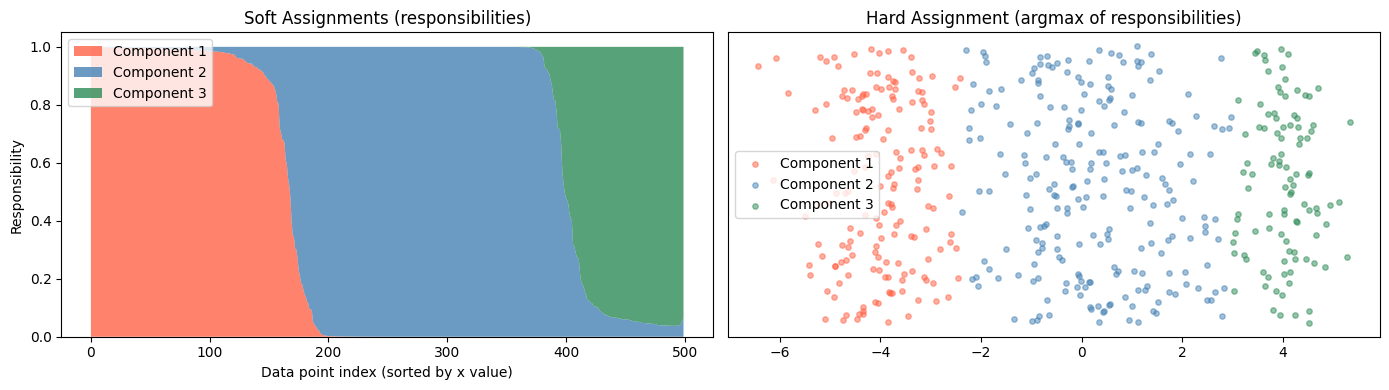


Sample responsibilities for 5 randomly chosen points:
       x       r_1       r_2       r_3    dominant
  -2.906    0.8533    0.1467    0.0000           1
  -1.850    0.0941    0.9059    0.0000           2
   0.863    0.0000    1.0000    0.0000           2
  -1.964    0.1456    0.8544    0.0000           2
  -4.481    0.9957    0.0043    0.0000           1


In [7]:
from scipy.special import logsumexp

def compute_responsibilities(x, pis, mus, sigmas):
    """E-step: compute soft assignments r[i, k] for each point i and component k."""
    K = len(pis)
    # log of pi_k * N(x | mu_k, sigma_k) — shape (N, K)
    log_num = np.column_stack([
        np.log(pi) + norm.logpdf(x, mu, sigma)
        for pi, mu, sigma in zip(pis, mus, sigmas)
    ])  # (N, K)
    log_denom = logsumexp(log_num, axis=1, keepdims=True)   # (N, 1)
    r = np.exp(log_num - log_denom)                          # (N, K)
    return r

# Use true parameters to compute responsibilities
r = compute_responsibilities(x_samples, pis_true, mus_true, sigmas_true)

# --- Visualise soft assignments along the x-axis ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: soft assignment as stacked bar per point (sorted by x for clarity)
sort_idx = np.argsort(x_samples)
x_sorted = x_samples[sort_idx]
r_sorted = r[sort_idx]

axes[0].stackplot(np.arange(N), r_sorted[:, 0], r_sorted[:, 1], r_sorted[:, 2],
                  labels=[f'Component {k+1}' for k in range(K)],
                  colors=colors, alpha=0.8)
axes[0].set_xlabel('Data point index (sorted by x value)')
axes[0].set_ylabel('Responsibility')
axes[0].set_title('Soft Assignments (responsibilities)')
axes[0].legend(loc='upper left')

# Right: scatter colored by dominant component (like hard assignment)
dominant = r.argmax(axis=1)
for k in range(K):
    mask = dominant == k
    axes[1].scatter(x_samples[mask], np.zeros(mask.sum()) + np.random.uniform(-0.1, 0.1, mask.sum()),
                    alpha=0.5, s=15, color=colors[k], label=f'Component {k+1}')
axes[1].set_yticks([])
axes[1].set_title('Hard Assignment (argmax of responsibilities)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Show a few example responsibilities
print('\nSample responsibilities for 5 randomly chosen points:')
print(f'{"x":>8}  {"r_1":>8}  {"r_2":>8}  {"r_3":>8}  {"dominant":>10}')
for i in np.random.choice(N, 5, replace=False):
    print(f'{x_samples[i]:8.3f}  {r[i,0]:8.4f}  {r[i,1]:8.4f}  {r[i,2]:8.4f}  {r[i].argmax()+1:>10}')

## Part 6 — Deriving EM: Step by Step From the Likelihood

---

### Step 1 — Recall: fitting a single Gaussian (Lec2)

For a single Gaussian the likelihood of $N$ observations is just a product:

$$p(X \mid \mu, \sigma) = \prod_{i=1}^{N} \mathcal{N}(x_i \mid \mu, \sigma)$$

Taking the log turns the product into a sum, and setting the derivative to zero gives a **clean closed form** for $\hat\mu$ and $\hat\sigma$.

---

### Step 2 — The GMM likelihood: why the log becomes a hurdle

#### Single Gaussian — log enters cleanly

$$\ell(\mu,\sigma) = \log \prod_{i=1}^{N} \mathcal{N}(x_i \mid \mu,\sigma)
= \sum_{i=1}^{N} \log \mathcal{N}(x_i \mid \mu,\sigma)$$

Expanding $\log \mathcal{N}$:

$$= \sum_{i=1}^{N} \left[ -\log\sigma - \tfrac{1}{2}\log 2\pi - \frac{(x_i-\mu)^2}{2\sigma^2} \right]$$

The log is applied directly to one Gaussian — every term separates. Setting $\partial\ell/\partial\mu = 0$ immediately gives $\hat\mu = \frac{1}{N}\sum_i x_i$.

#### GMM — the log is blocked by the sum

With $K$ components each observation can come from **any** component, so:

$$\ell(\theta) = \sum_{i=1}^{N} \log \left[\sum_{k=1}^{K} \pi_k \, \mathcal{N}(x_i \mid \mu_k, \sigma_k)\right]$$

The $\log$ now sits **outside** the $\sum_k$. Try to set $\partial\ell/\partial\mu_k = 0$:

$$\frac{\partial\ell}{\partial\mu_k}
= \sum_{i=1}^{N} \frac{\pi_k\,\mathcal{N}(x_i\mid\mu_k,\sigma_k)}{\sum_j \pi_j\,\mathcal{N}(x_i\mid\mu_j,\sigma_j)}
\cdot \frac{x_i - \mu_k}{\sigma_k^2} = 0$$

Setting this to zero gives:

$$\mu_k = \frac{\displaystyle\sum_i \overbrace{\frac{\pi_k\,\mathcal{N}(x_i\mid\mu_k,\sigma_k)}{\sum_j \pi_j\,\mathcal{N}(x_i\mid\mu_j,\sigma_j)}}^{\text{depends on all other } \mu_j,\sigma_j,\pi_j} x_i}{\displaystyle\sum_i \frac{\pi_k\,\mathcal{N}(x_i\mid\mu_k,\sigma_k)}{\sum_j \pi_j\,\mathcal{N}(x_i\mid\mu_j,\sigma_j)}}$$

**The solution for $\mu_k$ depends on all the other parameters** — there is no closed form.
The fraction in the numerator is exactly what we will call the **responsibility** $r_{ik}$.

#### Side-by-side summary

| | Single Gaussian | GMM |
|---|---|---|
| Likelihood | $\prod_i \mathcal{N}(x_i\mid\mu,\sigma)$ | $\prod_i \sum_k \pi_k\mathcal{N}(x_i\mid\mu_k,\sigma_k)$ |
| Log-likelihood | $\sum_i \log\mathcal{N}(x_i\mid\mu,\sigma)$ | $\sum_i \log\sum_k \pi_k\mathcal{N}(x_i\mid\mu_k,\sigma_k)$ |
| Log applied to | **one** Gaussian → expands cleanly | **sum of** Gaussians → log is stuck outside |
| $\partial\ell/\partial\mu=0$ | closed form $\hat\mu = \bar{x}$ | implicit equation, no closed form |

The log of a sum cannot be simplified further. This is the fundamental hurdle — and it is exactly why we need EM.

---

### Step 3 — Imagine we could see which component each point came from

Introduce hidden indicator variables:

$$z_{ik} = \begin{cases} 1 & \text{if point } i \text{ was generated by component } k \\ 0 & \text{otherwise} \end{cases}$$

The joint probability of observing $x_i$ **and** its label $z_i = k$ is:

$$p(x_i, z_{ik}=1 \mid \theta) = \pi_k \, \mathcal{N}(x_i \mid \mu_k, \sigma_k)$$

So the **complete-data** log-likelihood over all $N$ points is:

$$\ell_{\text{complete}}(\theta)
= \sum_{i=1}^{N}\sum_{k=1}^{K} z_{ik} \log\!\left[\pi_k \,\mathcal{N}(x_i \mid \mu_k, \sigma_k)\right]
= \sum_{i=1}^{N}\sum_{k=1}^{K} z_{ik} \underbrace{\left[\log \pi_k + \log \mathcal{N}(x_i \mid \mu_k, \sigma_k)\right]}_{\text{log is now INSIDE the bracket — no log of a sum!}}$$

#### Why this decouples everything

Expand $\log \mathcal{N}(x_i \mid \mu_k, \sigma_k) = -\log\sigma_k - \tfrac{1}{2}\log 2\pi - \frac{(x_i-\mu_k)^2}{2\sigma_k^2}$ and regroup by component:

$$\ell_{\text{complete}}(\theta)
= \underbrace{\sum_{k=1}^{K} \left(\sum_{i=1}^{N} z_{ik}\right) \log\pi_k}_{\text{depends only on } \boldsymbol{\pi}}
+ \sum_{k=1}^{K} \underbrace{\sum_{i=1}^{N} z_{ik}\!\left[-\log\sigma_k - \tfrac{1}{2}\log 2\pi - \frac{(x_i-\mu_k)^2}{2\sigma_k^2}\right]}_{\text{depends only on } \mu_k,\,\sigma_k \text{ — independent across } k}$$

**Each component $k$ now has its own isolated block** containing only $(\pi_k, \mu_k, \sigma_k)$.
Maximising over $\mu_1$ does not affect the terms for $\mu_2, \mu_3, \ldots$ at all.

Compare directly with the GMM observed log-likelihood from Step 2:

| | Observed $\ell$ | Complete-data $\ell_{\text{complete}}$ |
|---|---|---|
| Structure | $\sum_i \log \sum_k [\cdots]$ | $\sum_i \sum_k z_{ik} [\cdots]$ |
| Log hits | a **sum** — cannot expand | a **single term** — expands cleanly |
| Parameters | all $(\pi_k,\mu_k,\sigma_k)$ entangled | each component $k$ isolated |
| $\partial/\partial\mu_k = 0$ | implicit, no closed form | $\hat\mu_k = \frac{\sum_i z_{ik} x_i}{\sum_i z_{ik}}$ — weighted mean, closed form! |

The weighted mean $\hat\mu_k = \frac{\sum_i z_{ik} x_i}{\sum_i z_{ik}}$ has a clean interpretation:
sum up only the $x_i$ that truly belong to component $k$, then average them.

**The only problem:** we never observe $z_{ik}$. That is the gap EM fills.

---

### Step 4 — We can't see $z_{ik}$, so replace it with its expectation

We don't know $z_{ik}$, but we can compute its **expected value** given the data and current parameters $\theta^{\text{old}}$:

$$r_{ik} = \mathbb{E}[z_{ik} \mid x_i, \theta^{\text{old}}] = P(z_{ik}=1 \mid x_i, \theta^{\text{old}})$$

By **Bayes' theorem** (prior × likelihood / evidence):

$$\boxed{r_{ik} = \frac{\pi_k^{\text{old}} \, \mathcal{N}(x_i \mid \mu_k^{\text{old}}, \sigma_k^{\text{old}})}{\displaystyle\sum_{j=1}^{K} \pi_j^{\text{old}} \, \mathcal{N}(x_i \mid \mu_j^{\text{old}}, \sigma_j^{\text{old}})}}$$

- Numerator $= P(x_i \mid z_i{=}k)\, P(z_i{=}k)$ — how likely is $x_i$ if it came from component $k$, weighted by how common $k$ is.
- Denominator $= P(x_i)$ — total probability of $x_i$ across all components.

Now substitute $r_{ik}$ directly into $\ell_{\text{complete}}$ in place of $z_{ik}$:

$$\ell_{\text{complete}}(\theta) = \sum_{i=1}^{N}\sum_{k=1}^{K} \underbrace{z_{ik}}_{\text{unknown}} \left[\log \pi_k + \log \mathcal{N}(x_i \mid \mu_k, \sigma_k)\right]
\;\longrightarrow\;
\sum_{i=1}^{N}\sum_{k=1}^{K} \underbrace{r_{ik}}_{\text{known}} \left[\log \pi_k + \log \mathcal{N}(x_i \mid \mu_k, \sigma_k)\right]$$

That is all. No new object, no new name — just swap $z_{ik}$ for $r_{ik}$.
The decoupled structure from Step 3 is fully preserved: $r_{ik}$ is just a number in $[0,1]$,
so $\ell_{\text{complete}}$ remains a sum of $K$ independent blocks.
We can now maximise it with the same closed-form derivatives.

This substitution step is the **E-step**.

---

### Step 5 — Maximise $\ell_{\text{complete}}$ over $\theta$ — the M-step

$\ell_{\text{complete}}$ now **separates** into independent pieces for each parameter.

#### 5a — Update $\pi_k$

The $\pi_k$-dependent terms in $Q$:

$$Q_\pi = \sum_{k=1}^{K} \underbrace{\left(\sum_{i=1}^{N} r_{ik}\right)}_{N_k} \log \pi_k, \quad \text{subject to } \sum_k \pi_k = 1, \; \pi_k \ge 0$$

Use a Lagrange multiplier $\lambda$ for the constraint:

$$\frac{\partial}{\partial \pi_k}\left[\ell_{\text{complete}} - \lambda\!\left(\sum_k \pi_k - 1\right)\right] = \frac{N_k}{\pi_k} - \lambda = 0 \;\Longrightarrow\; \pi_k = \frac{N_k}{\lambda}$$

Sum over $k$: $\;\sum_k \pi_k = 1 \Rightarrow \lambda = \sum_k N_k = N$. Therefore:

$$\boxed{\pi_k^{\text{new}} = \frac{N_k}{N}, \qquad N_k = \sum_{i=1}^{N} r_{ik}}$$

Interpretation: $\pi_k$ is simply the **fraction of data points assigned to component $k$** (in expectation).

#### 5b — Update $\mu_k$

Only terms involving $\mu_k$:

$$Q_{\mu_k} = \sum_{i=1}^{N} r_{ik} \log \mathcal{N}(x_i \mid \mu_k, \sigma_k) = -\frac{1}{2\sigma_k^2} \sum_{i=1}^{N} r_{ik}(x_i - \mu_k)^2 + \text{const}$$

Set derivative to zero:

$$\frac{\partial Q_{\mu_k}}{\partial \mu_k} = \frac{1}{\sigma_k^2}\sum_{i=1}^{N} r_{ik}(x_i - \mu_k) = 0 \;\Longrightarrow\; \sum_i r_{ik} x_i = \mu_k N_k$$

$$\boxed{\mu_k^{\text{new}} = \frac{\displaystyle\sum_{i=1}^{N} r_{ik}\, x_i}{N_k}}$$

Interpretation: $\mu_k$ is the **weighted mean** of all data points, with weights = responsibilities.

#### 5c — Update $\sigma_k$

Similarly, only the $\sigma_k$-dependent terms:

$$Q_{\sigma_k} = -N_k \log\sigma_k - \frac{1}{2\sigma_k^2}\sum_{i=1}^{N} r_{ik}(x_i - \mu_k^{\text{new}})^2 + \text{const}$$

Set $\partial Q_{\sigma_k}/\partial \sigma_k = 0$:

$$-\frac{N_k}{\sigma_k} + \frac{1}{\sigma_k^3}\sum_{i=1}^{N} r_{ik}(x_i - \mu_k^{\text{new}})^2 = 0$$

$$\boxed{\sigma_k^{\text{new}} = \sqrt{\frac{\displaystyle\sum_{i=1}^{N} r_{ik}(x_i - \mu_k^{\text{new}})^2}{N_k}}}$$

Interpretation: $\sigma_k$ is the **weighted standard deviation** around the new mean.

---

### Summary: the EM loop

```
initialise  π, μ, σ  randomly

repeat:
    E-step:  r_ik  ←  Bayes' theorem  (Step 4)
    M-step:  N_k   ←  Σ_i r_ik
             π_k   ←  N_k / N
             μ_k   ←  Σ_i(r_ik · x_i) / N_k
             σ_k   ←  sqrt(Σ_i(r_ik · (x_i − μ_k)²) / N_k)
until  |ΔLL| < ε
```

**Monotone guarantee:** because $\ell_{\text{complete}}$ is a lower bound on $\ell(\theta)$ (via Jensen's inequality),
every M-step that improves $\ell_{\text{complete}}$ is guaranteed to improve $\ell$ too — the log-likelihood **never decreases**.

In [8]:
import numpy as np

# ── Gaussian PDF (manual, no scipy wrapper) ───────────────────────────────────
def gaussian_pdf(x, mu, sigma):
    """N(x | mu, sigma) computed directly from the formula."""
    coeff  = 1.0 / (sigma * np.sqrt(2 * np.pi))
    kernel = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    return coeff * kernel


# ── E-step: Bayes' theorem → responsibilities ─────────────────────────────────
def e_step(x, pis, mus, sigmas):
    """
    Compute r[i, k] = P(z_i = k | x_i, theta).

    From Bayes:  r_ik = pi_k * N(x_i | mu_k, sigma_k)
                        --------------------------------
                        sum_j  pi_j * N(x_i | mu_j, sigma_j)

    Returns r: array of shape (N, K).
    """
    N, K = len(x), len(pis)

    # Numerator: pi_k * N(x_i | mu_k, sigma_k)  shape (N, K)
    numer = np.column_stack([
        pis[k] * gaussian_pdf(x, mus[k], sigmas[k])
        for k in range(K)
    ])

    # Denominator: p(x_i) = sum over k of numerator row   shape (N, 1)
    denom = numer.sum(axis=1, keepdims=True)

    r = numer / denom          # soft assignments, each row sums to 1
    return r


# ── M-step: closed-form updates from the Q-function derivatives ───────────────
def m_step(x, r):
    """
    Update parameters by maximising the expected complete-data log-likelihood.

    Derived formulas:
        N_k     = sum_i r_ik                        (effective count)
        pi_k    = N_k / N                           (from Lagrange multiplier)
        mu_k    = sum_i(r_ik * x_i) / N_k          (weighted mean)
        sigma_k = sqrt(sum_i(r_ik*(x_i-mu_k)^2) / N_k)   (weighted std)

    Returns new_pis, new_mus, new_sigmas.
    """
    N, K = r.shape

    # Effective count per component
    Nk = r.sum(axis=0)                             # shape (K,)

    # pi update — from d/d(pi_k)[sum N_k log pi_k - lambda(sum pi_k - 1)] = 0
    new_pis = Nk / N

    # mu update — from d/d(mu_k)[sum r_ik * log N(x_i|mu_k,sigma_k)] = 0
    new_mus = (r * x[:, None]).sum(axis=0) / Nk   # shape (K,)

    # sigma update — from d/d(sigma_k)[...] = 0
    residuals_sq = (x[:, None] - new_mus[None, :]) ** 2   # (N, K)
    new_sigmas   = np.sqrt((r * residuals_sq).sum(axis=0) / Nk)

    return new_pis, new_mus, new_sigmas


# ── Log-likelihood — built from scratch, no wrappers ─────────────────────────
def log_likelihood(x, pis, mus, sigmas):
    """
    log p(X | theta) = sum_i log sum_k pi_k * N(x_i | mu_k, sigma_k)

    Uses log-sum-exp trick for numerical stability:
        log(sum_k exp(a_k)) = max(a) + log(sum_k exp(a_k - max(a)))
    """
    K = len(pis)
    # log of each term: log(pi_k * N(x_i | mu_k, sigma_k))  shape (N, K)
    log_terms = np.column_stack([
        np.log(pis[k])
        - np.log(sigmas[k])
        - 0.5 * np.log(2 * np.pi)
        - 0.5 * ((x - mus[k]) / sigmas[k]) ** 2
        for k in range(K)
    ])

    # log-sum-exp over K for each data point, then sum over N
    a_max     = log_terms.max(axis=1, keepdims=True)             # (N, 1)
    log_px    = a_max.squeeze() + np.log(                        # (N,)
                    np.exp(log_terms - a_max).sum(axis=1)
                )
    return log_px.sum()


# ── Verify: each formula matches what we expect on a toy example ──────────────
np.random.seed(0)
x_toy   = np.array([-4.1, -3.9, 0.3, 0.7, 4.2])
pis_toy = np.array([0.3, 0.5, 0.2])
mus_toy = np.array([-4.0, 0.5, 4.0])
sig_toy = np.array([0.8,  1.5, 0.6])

r_toy = e_step(x_toy, pis_toy, mus_toy, sig_toy)
print("E-step responsibilities (rows=points, cols=components):")
print(np.round(r_toy, 4))
print("Row sums (must all be 1):", r_toy.sum(axis=1).round(6))

new_pis, new_mus, new_sigs = m_step(x_toy, r_toy)
print("\nM-step updates on toy data:")
print(f"  π = {new_pis.round(4)}  (sum={new_pis.sum():.4f})")
print(f"  μ = {new_mus.round(4)}")
print(f"  σ = {new_sigs.round(4)}")

ll = log_likelihood(x_toy, pis_toy, mus_toy, sig_toy)
print(f"\nLog-likelihood on toy data: {ll:.4f}")


# ── Initialization for the full run (next cell) ───────────────────────────────
np.random.seed(7)
pis_init    = np.ones(K) / K
mus_init    = np.random.uniform(x_samples.min(), x_samples.max(), K)
sigmas_init = np.ones(K)

print("\nInitial parameters for full EM run:")
for k in range(K):
    print(f"  k={k+1}: π={pis_init[k]:.3f}  μ={mus_init[k]:.3f}  σ={sigmas_init[k]:.3f}")
print(f"  Initial LL: {log_likelihood(x_samples, pis_init, mus_init, sigmas_init):.2f}")

E-step responsibilities (rows=points, cols=components):
[[0.9919 0.0081 0.    ]
 [0.988  0.012  0.    ]
 [0.     1.     0.    ]
 [0.     1.     0.    ]
 [0.     0.048  0.952 ]]
Row sums (must all be 1): [1. 1. 1. 1. 1.]

M-step updates on toy data:
  π = [0.396  0.4136 0.1904]  (sum=1.0000)
  μ = [-4.0002  0.5425  4.2   ]
  σ = [0.1    0.7413 0.0019]

Log-likelihood on toy data: -9.8718

Initial parameters for full EM run:
  k=1: π=0.333  μ=-5.539  σ=1.000
  k=2: π=0.333  μ=2.745  σ=1.000
  k=3: π=0.333  μ=-1.276  σ=1.000
  Initial LL: -1391.16


## Part 7 — Running EM and Watching It Converge

Let's run EM for many iterations and track:
1. How the log-likelihood increases each step (it must never decrease!).
2. How the estimated parameters approach the true values.

We also check the **convergence criterion**: stop when the change in log-likelihood
between iterations is smaller than a threshold $\epsilon$.

Converged at iteration 89  (ΔLL < 1e-06)


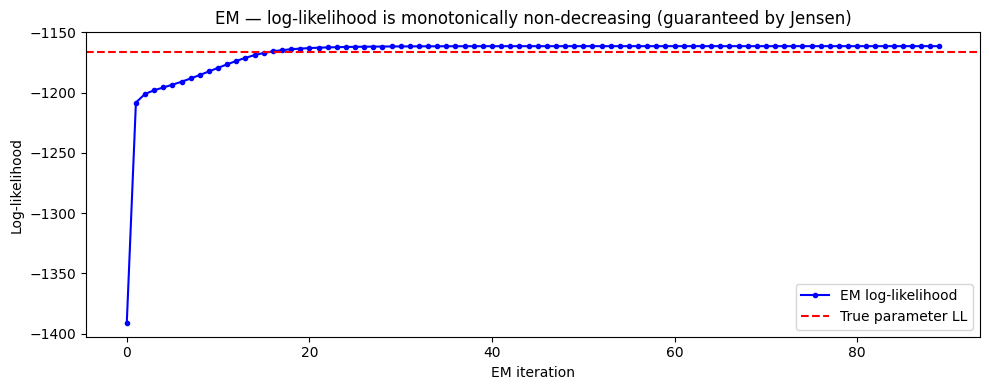


Final estimated vs. true parameters (sorted by μ):
         π_est   π_true      μ_est   μ_true      σ_est   σ_true
k=1     0.324    0.300     -4.005   -4.000      0.813    0.800
k=2     0.495    0.500      0.296    0.500      1.562    1.500
k=3     0.181    0.200      4.051    4.000      0.489    0.600


In [9]:
max_iter = 200
tol      = 1e-6

pis    = pis_init.copy()
mus    = mus_init.copy()
sigmas = sigmas_init.copy()

ll_history    = [log_likelihood(x_samples, pis, mus, sigmas)]
param_history = [(pis.copy(), mus.copy(), sigmas.copy())]

for it in range(max_iter):
    # ── E-step: responsibilities from Bayes' theorem ──────────────────────────
    r = e_step(x_samples, pis, mus, sigmas)

    # ── M-step: closed-form updates from Q-function derivatives ──────────────
    pis, mus, sigmas = m_step(x_samples, r)

    ll = log_likelihood(x_samples, pis, mus, sigmas)
    ll_history.append(ll)
    param_history.append((pis.copy(), mus.copy(), sigmas.copy()))

    # Verify monotone increase (Jensen's guarantee — should never fire)
    assert ll >= ll_history[-2] - 1e-8, f"LL decreased at iter {it}! Bug in implementation."

    if abs(ll_history[-1] - ll_history[-2]) < tol:
        print(f"Converged at iteration {it + 1}  (ΔLL < {tol})")
        break

# ── Plot LL curve ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ll_history, 'b-o', ms=3, label='EM log-likelihood')
ax.axhline(log_likelihood(x_samples, pis_true, mus_true, sigmas_true),
           color='red', ls='--', lw=1.5, label='True parameter LL')
ax.set_xlabel('EM iteration')
ax.set_ylabel('Log-likelihood')
ax.set_title('EM — log-likelihood is monotonically non-decreasing (guaranteed by Jensen)')
ax.legend()
plt.tight_layout()
plt.show()

# ── Final parameter comparison ────────────────────────────────────────────────
print('\nFinal estimated vs. true parameters (sorted by μ):')
our_order  = np.argsort(mus)
true_order = np.argsort(mus_true)
print(f'{"":5} {"π_est":>8} {"π_true":>8}   {"μ_est":>8} {"μ_true":>8}   {"σ_est":>8} {"σ_true":>8}')
for rank in range(K):
    ke, kt = our_order[rank], true_order[rank]
    print(f'k={rank+1}  {pis[ke]:8.3f} {pis_true[kt]:8.3f}   '
          f'{mus[ke]:8.3f} {mus_true[kt]:8.3f}   '
          f'{sigmas[ke]:8.3f} {sigmas_true[kt]:8.3f}')

## Part 8 — Visualising EM Snapshots

Let's see how the fitted mixture evolves across a few key iterations.
Initially the components overlap poorly; as EM progresses they separate and fit the data.

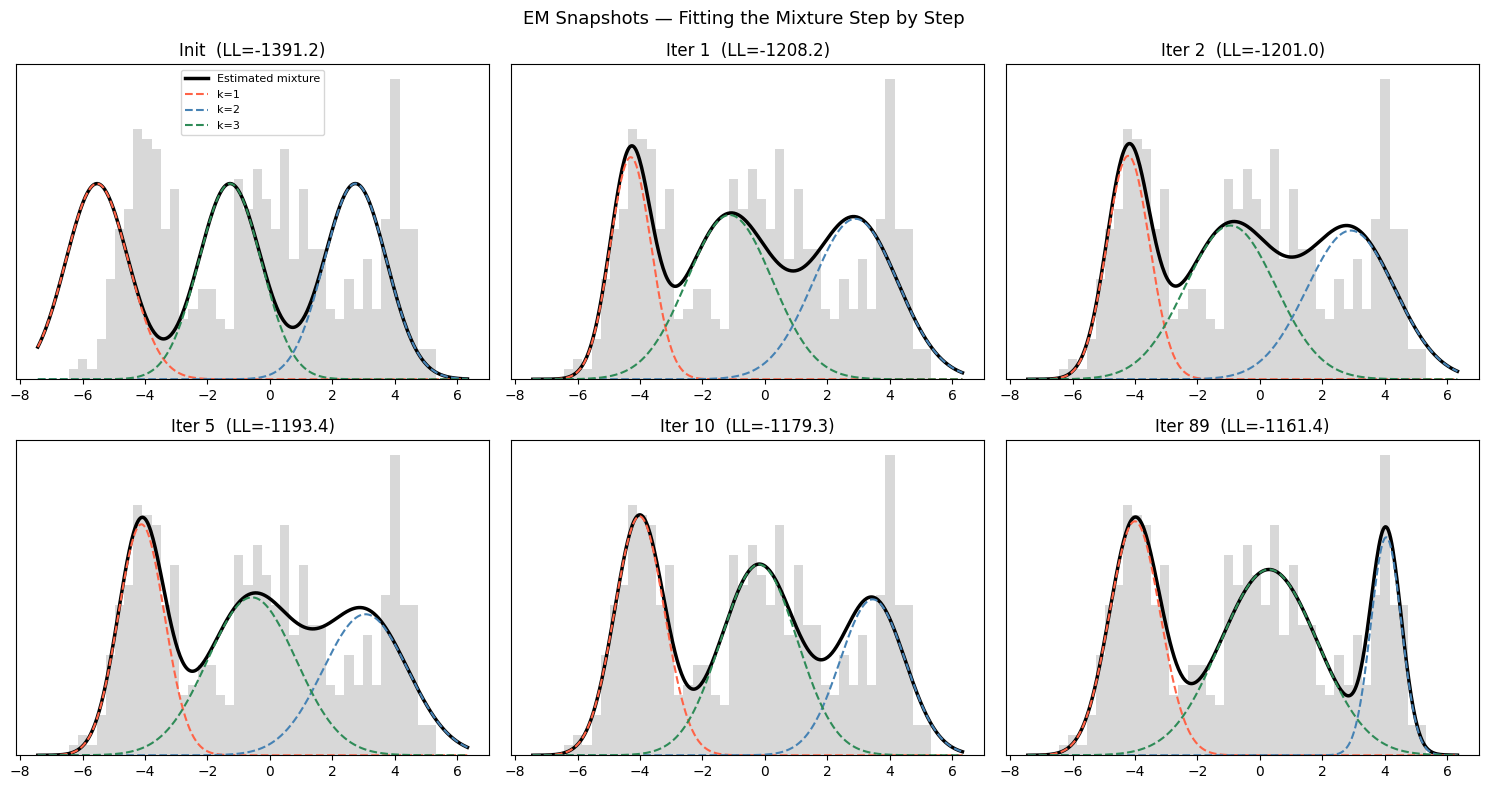

In [12]:
x_plot = np.linspace(x_samples.min() - 1, x_samples.max() + 1, 400)
snapshots = [0, 1, 2, 5, 10, len(param_history) - 1]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, snap_idx in zip(axes.flat, snapshots):
    pis_s, mus_s, sigmas_s = param_history[snap_idx]
    mixture_s = sum(pi * norm.pdf(x_plot, mu, sigma)
                    for pi, mu, sigma in zip(pis_s, mus_s, sigmas_s))

    ax.hist(x_samples, bins=40, density=True, alpha=0.3, color='gray')
    ax.plot(x_plot, mixture_s, 'k-', lw=2.5, label='Estimated mixture')
    for k in range(K):
        ax.plot(x_plot, pis_s[k] * norm.pdf(x_plot, mus_s[k], sigmas_s[k]),
                ls='--', lw=1.5, color=colors[k], label=f'k={k+1}')

    label = 'Init' if snap_idx == 0 else f'Iter {snap_idx}'
    ll_s = ll_history[snap_idx]
    ax.set_title(f'{label}  (LL={ll_s:.1f})')
    ax.set_yticks([])
    if snap_idx == 0:
        ax.legend(fontsize=8)

plt.suptitle('EM Snapshots — Fitting the Mixture Step by Step', fontsize=13)
plt.tight_layout()
plt.show()

### Animation — Watching EM Converge in 1D

The cell below saves `em_animation_1d.gif` — frame by frame how the mixture PDF
and individual components evolve from the bad initialisation toward the true distribution.

Saved: em_animation_1d.gif


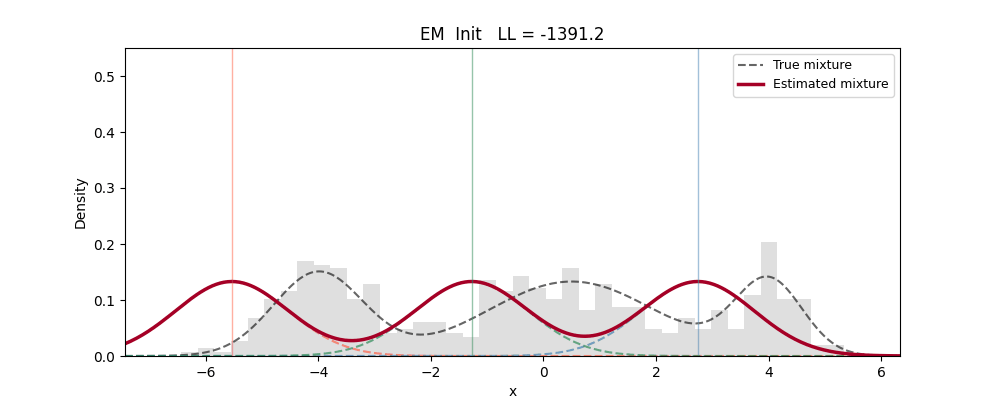

In [11]:
import matplotlib.animation as animation
from IPython.display import Image as IPImage, display
from scipy.stats import norm

x_plot = np.linspace(x_samples.min() - 1, x_samples.max() + 1, 400)
colors_anim = ['tomato', 'steelblue', 'seagreen']
cmap = plt.cm.RdYlGn

fig_1d, ax_1d = plt.subplots(figsize=(10, 4))

def draw_frame_1d(frame_idx):
    ax_1d.clear()
    pis_f, mus_f, sigmas_f = param_history[frame_idx]
    ll_f = ll_history[frame_idx]
    t = frame_idx / max(len(param_history) - 1, 1)

    mixture_f = sum(pi * norm.pdf(x_plot, mu, sigma)
                    for pi, mu, sigma in zip(pis_f, mus_f, sigmas_f))
    mixture_true = sum(pi * norm.pdf(x_plot, mu, sigma)
                       for pi, mu, sigma in zip(pis_true, mus_true, sigmas_true))

    ax_1d.hist(x_samples, bins=40, density=True, alpha=0.25, color='gray')
    ax_1d.plot(x_plot, mixture_true, 'k--', lw=1.5, alpha=0.6, label='True mixture')

    # individual components
    for k in range(K):
        ax_1d.plot(x_plot, pis_f[k] * norm.pdf(x_plot, mus_f[k], sigmas_f[k]),
                   ls='--', lw=1.5, color=colors_anim[k], alpha=0.7)

    # mixture curve coloured by progress (red → green)
    ax_1d.plot(x_plot, mixture_f, color=cmap(t), lw=2.5, label='Estimated mixture')

    # component mean markers
    for k in range(K):
        ax_1d.axvline(mus_f[k], color=colors_anim[k], lw=1, alpha=0.5)

    iter_label = 'Init' if frame_idx == 0 else f'Iter {frame_idx}'
    ax_1d.set_title(f'EM  {iter_label}   LL = {ll_f:.1f}', fontsize=12)
    ax_1d.set_xlim(x_plot[0], x_plot[-1])
    ax_1d.set_ylim(0, 0.55)
    ax_1d.set_xlabel('x')
    ax_1d.set_ylabel('Density')
    ax_1d.legend(loc='upper right', fontsize=9)

# pick a subset of frames so the gif is not too long
n_frames = len(param_history)
frame_indices = sorted(set(
    list(range(min(10, n_frames))) +                          # every early iter
    list(range(0, n_frames, max(1, n_frames // 30))) +        # evenly spaced
    [n_frames - 1]                                            # final
))

ani_1d = animation.FuncAnimation(
    fig_1d, draw_frame_1d,
    frames=frame_indices, interval=300, repeat=True
)

gif_1d = 'em_animation_1d.gif'
ani_1d.save(gif_1d, writer='pillow', fps=4)
plt.close(fig_1d)

print(f'Saved: {gif_1d}')
display(IPImage(filename=gif_1d))

## Part 9 — Comparing With sklearn

`sklearn.mixture.GaussianMixture` is a production-grade implementation of EM.
Let's verify our from-scratch result matches it.

In [13]:
from sklearn.mixture import GaussianMixture

gmm_sk = GaussianMixture(n_components=3, random_state=7, covariance_type='full')
gmm_sk.fit(x_samples.reshape(-1, 1))

# Sort both by estimated mean
sk_order   = np.argsort(gmm_sk.means_.ravel())
our_order  = np.argsort(mus)
true_order = np.argsort(mus_true)

print('Comparing: Our EM  |  sklearn  |  True')
print(f'{"":<5} {"μ_ours":>8} {"μ_sk":>8} {"μ_true":>8}   {"σ_ours":>8} {"σ_sk":>8} {"σ_true":>8}')
for rank in range(K):
    k_our  = our_order[rank]
    k_sk   = sk_order[rank]
    k_true = true_order[rank]
    sigma_sk = np.sqrt(gmm_sk.covariances_.ravel()[k_sk])
    print(f'k={rank+1}  {mus[k_our]:8.3f} {gmm_sk.means_.ravel()[k_sk]:8.3f} {mus_true[k_true]:8.3f}   '
          f'{sigmas[k_our]:8.3f} {sigma_sk:8.3f} {sigmas_true[k_true]:8.3f}')

print(f'\nOur LL:     {ll_history[-1]:.2f}')
print(f'sklearn LL: {gmm_sk.lower_bound_ * len(x_samples):.2f}  (per-sample lower bound × N)')

Comparing: Our EM  |  sklearn  |  True
        μ_ours     μ_sk   μ_true     σ_ours     σ_sk   σ_true
k=1    -4.005   -3.928   -4.000      0.813    0.866    0.800
k=2     0.296    0.251    0.500      1.562    1.308    1.500
k=3     4.051    3.938    4.000      0.489    0.588    0.600

Our LL:     -1161.36
sklearn LL: -1163.30  (per-sample lower bound × N)


## Part 11 — 2D Gaussian Mixture

Everything extends naturally to two (or more) dimensions.
The 1D Gaussian $\mathcal{N}(x \mid \mu_k, \sigma_k)$ becomes a multivariate Gaussian
$\mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$.

The covariance matrix $\boldsymbol{\Sigma}_k$ now captures both the **spread** in each direction
and the **correlation** between dimensions — giving each component its own elliptical shape.

The EM update rules are the same in spirit; only the formulas for $\boldsymbol{\mu}_k$
and $\boldsymbol{\Sigma}_k$ become matrix operations.

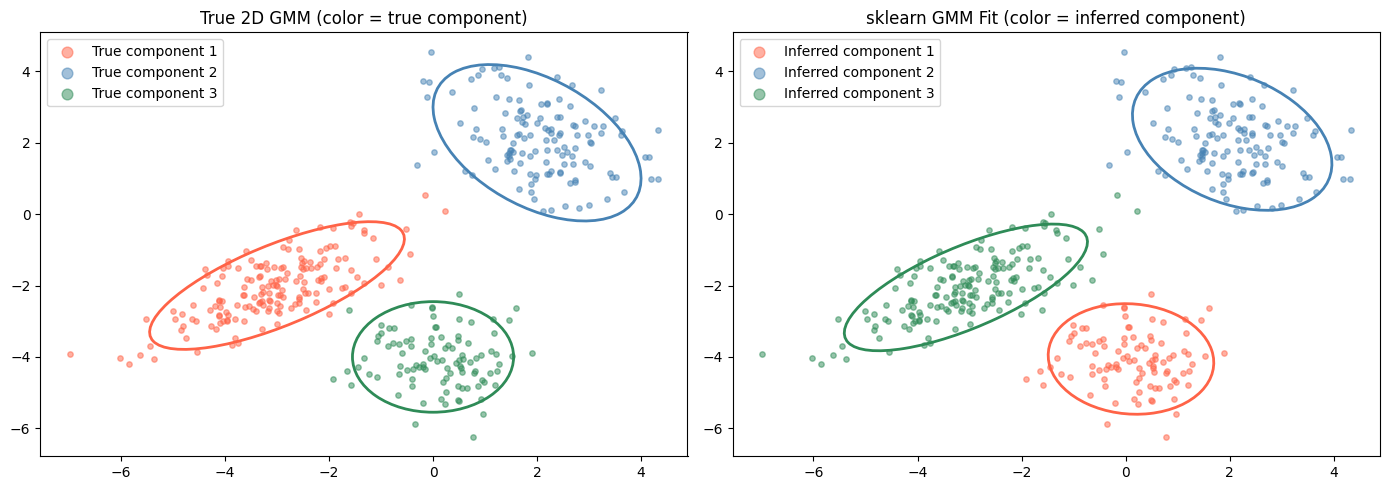

In [14]:
from scipy.stats import multivariate_normal
from matplotlib.patches import Ellipse

np.random.seed(42)

# True 2D GMM
pis_2d  = [0.4, 0.35, 0.25]
mus_2d  = [np.array([-3, -2]), np.array([2, 2]), np.array([0, -4])]
covs_2d = [
    np.array([[1.5, 0.8], [0.8, 0.8]]),
    np.array([[1.0, -0.5], [-0.5, 1.2]]),
    np.array([[0.6, 0.0], [0.0, 0.6]]),
]
N2 = 400

# Sample from the 2D GMM
z2 = np.random.choice(3, size=N2, p=pis_2d)
X2 = np.vstack([
    np.random.multivariate_normal(mus_2d[zi], covs_2d[zi])
    for zi in z2
])

# Fit with sklearn
gmm_2d = GaussianMixture(n_components=3, random_state=0, n_init=5)
gmm_2d.fit(X2)
labels_2d = gmm_2d.predict(X2)

def draw_ellipse(ax, mean, cov, n_std=2, color='black', lw=2):
    """Draw a 2D confidence ellipse for a Gaussian."""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor=color, fc='None', lw=lw)
    ax.add_patch(ellipse)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: true labels
for k in range(3):
    mask = z2 == k
    axes[0].scatter(X2[mask, 0], X2[mask, 1], alpha=0.5, s=15,
                    color=colors[k], label=f'True component {k+1}')
    draw_ellipse(axes[0], mus_2d[k], covs_2d[k], color=colors[k])
axes[0].set_title('True 2D GMM (color = true component)')
axes[0].legend(markerscale=2)

# Right: sklearn inferred labels
for k in range(3):
    mask = labels_2d == k
    axes[1].scatter(X2[mask, 0], X2[mask, 1], alpha=0.5, s=15,
                    color=colors[k], label=f'Inferred component {k+1}')
    draw_ellipse(axes[1], gmm_2d.means_[k], gmm_2d.covariances_[k], color=colors[k])
axes[1].set_title('sklearn GMM Fit (color = inferred component)')
axes[1].legend(markerscale=2)

plt.tight_layout()
plt.show()

### Animation — Watching EM Converge in 2D

The cell below runs EM from scratch on the 2D data and saves `em_animation_2d.gif`.
Each frame shows the current confidence ellipses and component means evolving toward the true clusters.

In [ ]:
import matplotlib.animation as animation
from matplotlib.patches import Ellipse
from IPython.display import Image as IPImage, display
from scipy.stats import multivariate_normal as mvn

# ── Run 2D EM from scratch ────────────────────────────────────────────────────
def e_step_2d(X, pis, mus, covs):
    """Responsibilities for 2D GMM."""
    N, K = X.shape[0], len(pis)
    numer = np.column_stack([
        pis[k] * mvn(mean=mus[k], cov=covs[k]).pdf(X)
        for k in range(K)
    ])
    return numer / numer.sum(axis=1, keepdims=True)

def m_step_2d(X, r):
    """Parameter updates for 2D GMM."""
    N, K = r.shape
    Nk      = r.sum(axis=0)
    new_pis = Nk / N
    new_mus = [(r[:, k][:, None] * X).sum(axis=0) / Nk[k] for k in range(K)]
    new_covs = []
    for k in range(K):
        diff  = X - new_mus[k]                          # (N, 2)
        wcov  = (r[:, k][:, None, None] * diff[:, :, None] * diff[:, None, :]).sum(axis=0) / Nk[k]
        new_covs.append(wcov)
    return new_pis, new_mus, new_covs

np.random.seed(42)
K2 = 3

# Initialise: equal weights, random means near data, spherical covariances
pis2  = np.ones(K2) / K2
mus2  = [X2[np.random.randint(len(X2))] + np.random.randn(2) for _ in range(K2)]
covs2 = [np.eye(2) * 2.0 for _ in range(K2)]

param_hist_2d = [(pis2.copy(), [m.copy() for m in mus2], [c.copy() for c in covs2])]

for _ in range(60):
    r2          = e_step_2d(X2, pis2, mus2, covs2)
    pis2, mus2, covs2 = m_step_2d(X2, r2)
    param_hist_2d.append((pis2.copy(), [m.copy() for m in mus2], [c.copy() for c in covs2]))

# ── Animation ─────────────────────────────────────────────────────────────────
def make_ellipse(mean, cov, n_std=2, **kwargs):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle  = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h   = 2 * n_std * np.sqrt(vals)
    return Ellipse(xy=mean, width=w, height=h, angle=angle, **kwargs)

colors_2d = ['tomato', 'steelblue', 'seagreen']
cmap2d    = plt.cm.RdYlGn

fig_2d, ax_2d = plt.subplots(figsize=(7, 6))

def draw_frame_2d(frame_idx):
    ax_2d.clear()
    pis_f, mus_f, covs_f = param_hist_2d[frame_idx]
    t = frame_idx / max(len(param_hist_2d) - 1, 1)

    # data points colored by current dominant component
    r_f = e_step_2d(X2, pis_f, mus_f, covs_f)
    dom = r_f.argmax(axis=1)

    for k in range(K2):
        mask = dom == k
        ax_2d.scatter(X2[mask, 0], X2[mask, 1],
                      alpha=0.35, s=12, color=colors_2d[k])

    # true ellipses (dashed black)
    for k in range(K2):
        el = make_ellipse(mus_2d[k], covs_2d[k], edgecolor='black',
                          fc='none', lw=1.2, ls='--', alpha=0.5)
        ax_2d.add_patch(el)

    # estimated ellipses (solid, progress-coloured outline)
    progress_color = cmap2d(t)
    for k in range(K2):
        el = make_ellipse(mus_f[k], covs_f[k],
                          edgecolor=colors_2d[k], fc='none', lw=2.2)
        ax_2d.add_patch(el)
        ax_2d.scatter(*mus_f[k], color=colors_2d[k],
                      edgecolors='black', s=60, zorder=5)

    # true means (×)
    for k in range(K2):
        ax_2d.scatter(*mus_2d[k], marker='x', color='black', s=80, lw=2, zorder=6)

    iter_label = 'Init' if frame_idx == 0 else f'Iter {frame_idx}'
    ax_2d.set_title(f'2D EM  {iter_label}   (dashed = true)', fontsize=11)
    ax_2d.set_xlim(-8, 7); ax_2d.set_ylim(-8, 6)
    ax_2d.set_xlabel('$x_1$'); ax_2d.set_ylabel('$x_2$')

n2 = len(param_hist_2d)
frame_idx_2d = sorted(set(
    list(range(min(8, n2))) +
    list(range(0, n2, max(1, n2 // 25))) +
    [n2 - 1]
))

ani_2d = animation.FuncAnimation(
    fig_2d, draw_frame_2d,
    frames=frame_idx_2d, interval=300, repeat=True
)

gif_2d = 'em_animation_2d.gif'
ani_2d.save(gif_2d, writer='pillow', fps=4)
plt.close(fig_2d)

print(f'Saved: {gif_2d}')
display(IPImage(filename=gif_2d))

## Summary

| Concept | Key Formula / Idea |
|---------|--------------------|
| GMM density | $p(x) = \sum_k \pi_k \mathcal{N}(x\mid\mu_k,\sigma_k)$ |
| Parameters | mixing weights $\pi_k$, means $\mu_k$, std devs $\sigma_k$ |
| Responsibility (E-step) | $r_{ik} = \pi_k \mathcal{N}(x_i\mid\mu_k,\sigma_k) \;/\; p(x_i)$ |
| M-step update | weighted mean and variance using responsibilities as weights |
| Log-likelihood | always increases each EM iteration |
| Model selection | BIC / AIC scan over $K$ |
| 2D extension | replace $\sigma_k$ with covariance matrix $\boldsymbol{\Sigma}_k$ |

**What comes next?**
GMMs are a special case of the broader family of **latent variable models**.
The same EM recipe applies to Hidden Markov Models, Probabilistic PCA, and beyond.
In Lec4 we will see how **autoencoders** and **VAEs** learn continuous latent representations
rather than discrete component memberships.